# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

Se observa lo siguiente tras analizar la información general del dataset:

- Valores nulos: El dataset cuenta con un total de 40,000 registros y no tiene valores ausentes, ya que todas las columnas presentan 40,000 valores no nulos.

- Tipos de datos incorrectos: La columna date es de tipo de dato object y debería ser de tipo datetime para poder manipular correctamente las fechas en análisis posteriores. Las demás columnas presentan tipos de datos adecuados para su naturaleza.

Pasos a seguir:

- Convertir la columna date al formato de fecha correcto utilizando pd.to_datetime(df['date']).

In [6]:
# Cambio de tipo de dato de la columna date
df['date'] = pd.to_datetime(df['date'])

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [7]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [8]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [9]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [11]:
# Resumen estadístico de usuarios que se convirtieron
# Filtrar usuarios que se convirtieron
clientes_convertidos = df[df['converted'] == 1]

# Ver resumen estadístico
clientes_convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts()) #completa el código)
print(df['region'].value_counts())
print(df['dispositivo'].value_counts())
print(df['traffic_source'].value_counts())
print(df['user_type'].value_counts())
print(df['converted'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
0    34294
1     5706
Name: converted, dtype: int64


In [39]:
# Calcular Q1, Q3 e IQR para la variable gasto (solo usuarios convertidos)

q1 = df.loc[df["converted"] == 1, "gasto"].quantile(0.25)
q3 = df.loc[df["converted"] == 1, "gasto"].quantile(0.75)

iqr = q3 - q1

# Límite superior
limite_superior = q3 + 1.5 * iqr

# Valor máximo
valor_maximo = df.loc[df["converted"] == 1, "gasto"].max()

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Valor máximo: {valor_maximo:.2f}")

if valor_maximo > limite_superior:
    print("\nConclusión: El valor máximo es un outlier según la regla del IQR.")
else:
    print("\nConclusión: El valor máximo NO es un outlier según la regla del IQR.")

Q1: 42.95
Q3: 80.37
IQR: 37.42
Límite superior: 136.50
Valor máximo: 303.68

Conclusión: El valor máximo es un outlier según la regla del IQR.


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

Se observa lo siguiente tras revisar la consistencia y la distribución de los valores en las columnas del dataset:

- Consistencia de los datos: Todas las columnas presentan valores coherentes dentro de los rangos esperados.

- Variables categóricas: Las columnas como landing, user_type, dispositivo, region y traffic_source no muestran categorías duplicadas por errores de escritura, espacios en blanco o problemas de capitalización.

- Variables numéricas: La columna converted solo contiene valores binarios esperados (0 y 1). Por su parte, la columna gasto presenta valores numéricos positivos y coherentes, el valor máximo de gasto es 303.68, mientras que el 75% de los usuarios convertidos gastó menos de 80.37.

Conclusión: Todas las columnas tienen valores esperados y la estructura de los datos es limpia.

Pasos a seguir:

- No se requieren acciones de depuración o corrección de categorías mal escritas.

- Continuar con el proceso de análisis de datos y la evaluación del experimento.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [18]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A')] #completa el código
gasto_B = df[(df['landing'] == 'B')] #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

In [19]:
# Separar en grupo A y grupo B
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B= df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [20]:
# Aplicar prueba
# Ejecutar prueba t y guardar resultados
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula ($H_0$). El valor de p (p-value) obtenido en la prueba estadística es menor que el nivel de significancia estándar ($\alpha = 0.05$), lo que demuestra que existen diferencias estadísticamente significativas en el gasto promedio de los usuarios entre ambas versiones de la página.

**Interpretación de negocio:**  
Los resultados indican que el cambio en el diseño de la página de aterrizaje (Landing Page) impactó de forma directa y positiva en el comportamiento de compra. Los usuarios que interactuaron con la nueva versión de la página (Página B) registraron un gasto promedio significativamente mayor en comparación con los que utilizaron la versión anterior (Página A). Por lo tanto, desde una perspectiva de negocio, se recomienda implementar de manera definitiva la nueva página, ya que ha demostrado ser más efectiva para incrementar los ingresos por usuario.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba 

**Hipótesis:**
- **Hipótesis nula (H₀):**
  La tasa de conversión de la página A es igual a la tasa de conversión de la página B (pA = pB). No existe una diferencia estadísticamente significativa entre ambas.
- **Hipótesis alternativa (H₁):**
  La tasa de conversión de la página A es diferente a la tasa de conversión de la página B (pA ≠ pB). Existe una diferencia estadísticamente significativa entre ambas.

In [21]:
# Número de usuarios convertidos por página
converted = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
total = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n")
print(converted)
print("\nTotal de usuarios por página:\n")
print(total)

Usuarios convertidos por página:

landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:

landing
A    19982
B    20018
Name: converted, dtype: int64


In [23]:
# Tasas de conversión
conversion_rate = converted / total

print("Tasa de conversión:")
print((conversion_rate * 100).round(2).astype(str) + "%")

Tasa de conversión:
landing
A    12.57%
B    15.96%
Name: converted, dtype: object


In [22]:
# Aplicar prueba
# Prueba Z para dos proporciones
estadistico, p_value = proportions_ztest(
    converted,
    total
)
# Visualizar resultados
print(f"Estadístico Z: {estadistico:.4f}")
print(f"Valor p: {p_value:.10f}")

Estadístico Z: -9.6774
Valor p: 0.0000000000


### 📝 Conclusión e interpretación

**Decisión:**  

Como el valor p = 3.76 × 10⁻²², es mucho menor que 0.05, se rechaza la hipótesis nula (H₀).

Existe evidencia estadísticamente significativa de que las tasas de conversión de las páginas A y B son diferentes.

**Interpretación de negocio:**  
La prueba Z para dos proporciones mostró una diferencia estadísticamente significativa entre las tasas de conversión de las páginas A y B (p < 0.05). La página B obtuvo una tasa de conversión de 15.96%, mientras que la página A alcanzó 12.57%. Esto indica que la versión B convierte un mayor porcentaje de usuarios y representa una mejor alternativa para incrementar las conversiones. Como recomendación para el equipo de negocio, se sugiere implementar la página B como versión principal, ya que puede generar un mayor número de usuarios convertidos y mejorar el rendimiento de la campaña.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):**
  No existe una asociación entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`). La conversión es independiente de la fuente de tráfico.
- **Hipótesis alternativa (H₁):**
  Existe una asociación entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`). La conversión depende de la fuente de tráfico.

In [24]:
#Crear la tabla de contingencia

tabla = pd.crosstab(df["traffic_source"], df["converted"])

print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [25]:
# Aplicar prueba

chi2, p_value, dof, expected = chi2_contingency(tabla)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

Chi-cuadrado: 8.6621
Valor p: 0.034138
Grados de libertad: 3


In [26]:
#Ver las tasas de conversión por fuente
conversion = (
    df.groupby("traffic_source")["converted"]
      .mean()
      .sort_values(ascending=False)
)

print((conversion*100).round(2))

traffic_source
Email       14.99
Ads         14.74
Referral    13.88
Organic     13.79
Name: converted, dtype: float64


In [27]:
#El valor p es el que guía la decisión. Lo comparamos con alpha de 0.05, que representa un 5% de riesgo.
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  

Como el valor p = 0.034138 es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula (H₀). Por lo tanto, existe evidencia estadísticamente significativa para afirmar que la fuente de tráfico (traffic_source) y la conversión (converted) están asociadas.

**Interpretación de negocio:**  

Los resultados indican que la fuente de tráfico influye en la probabilidad de que un usuario realice una conversión. Aunque las diferencias en las tasas de conversión no son muy amplias, la prueba estadística demuestra que no se deben únicamente al azar.

Al analizar las tasas de conversión por canal, se observa que:

Email presenta la mayor tasa de conversión (14.99%), lo que sugiere que es el canal más efectivo para generar conversiones.
Ads ocupa el segundo lugar con una tasa de 14.74%, mostrando también un buen desempeño.
Referral (13.88%) y Organic (13.79%) presentan tasas de conversión ligeramente inferiores.

Desde una perspectiva de negocio, estos resultados sugieren que la empresa podría priorizar las campañas de Email y Ads, ya que son los canales con mejor rendimiento en términos de conversión. Asimismo, sería recomendable analizar las estrategias utilizadas en estos canales para replicar sus buenas prácticas en los canales Referral y Organic, con el fin de mejorar su desempeño y aumentar el número total de conversiones.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):**
  No existe una asociación entre el tipo de usuario (`user_type`) y la conversión (`converted`). La conversión es independiente del tipo de usuario.
- **Hipótesis alternativa (H₁):**
  Existe una asociación entre el tipo de usuario (`user_type`) y la conversión (`converted`). La conversión depende del tipo de usuario.

In [28]:
# Tabla de contingencia
tabla = pd.crosstab(df["user_type"], df["converted"])

print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [29]:
# Prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

Chi-cuadrado: 0.5135
Valor p: 0.473634
Grados de libertad: 1


In [30]:
# Tasas de conversión
conversion = (
    df.groupby("user_type")["converted"]
      .mean()
      .sort_values(ascending=False)
)

print("\nTasas de conversión (%)")
print((conversion*100).round(2))


Tasas de conversión (%)
user_type
Nuevo         14.36
Recurrente    14.09
Name: converted, dtype: float64


In [33]:
#El valor p es el que guía la decisión. Lo comparamos con alpha de 0.05, que representa un 5% de riesgo.
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Como el valor p = 0.4736 es mayor que el nivel de significancia de 0.05, no se rechaza la hipótesis nula (H₀). Esto indica que no existe evidencia estadísticamente significativa para afirmar que el tipo de usuario (user_type) y la conversión (converted) estén asociados.

**Interpretación de negocio:**  
Los resultados sugieren que, dentro del contexto de este experimento, el tipo de usuario no influye de manera significativa en la probabilidad de conversión. Las diferencias observadas entre los distintos tipos de usuarios pueden atribuirse al azar y no representan una evidencia suficiente para segmentar las estrategias de marketing únicamente con base en esta variable.

En consecuencia, la empresa debería priorizar otros factores que sí demostraron tener un impacto significativo en la conversión, como la versión de la página de destino y la fuente de tráfico, antes que enfocar sus esfuerzos en el tipo de usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

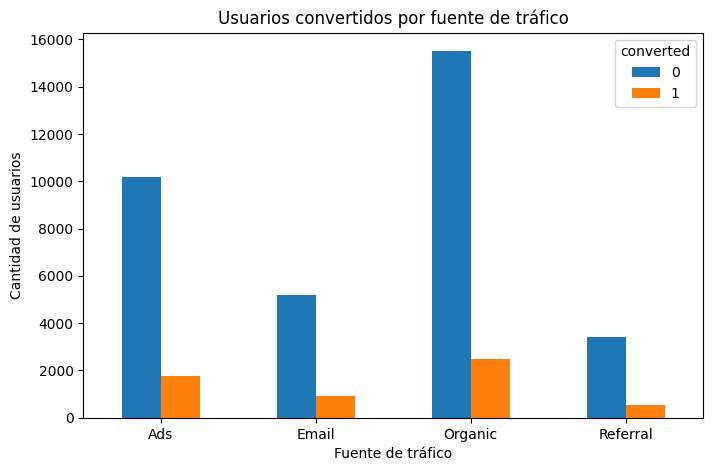

In [34]:
#Gráfico de cantidades
pd.crosstab(df["traffic_source"], df["converted"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Usuarios convertidos por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.show()

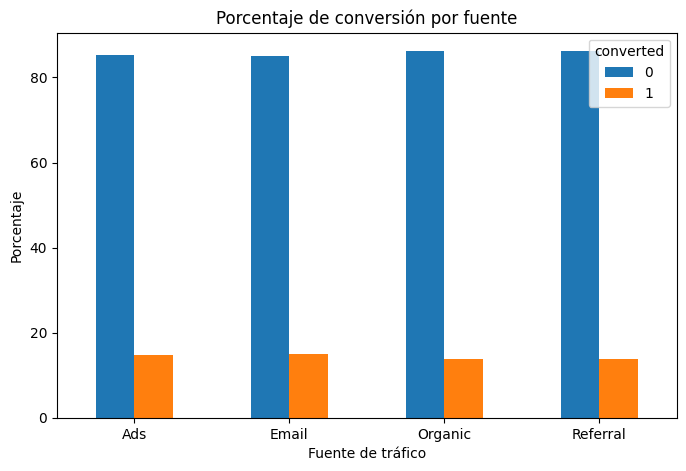

In [36]:
#Gráfico de porcentajes
(
pd.crosstab(
    df["traffic_source"],
    df["converted"],
    normalize="index"
)*100).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Porcentaje de conversión por fuente")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

- El gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron para cada fuente de tráfico. Se observa que Ads y Organic concentran el mayor volumen de usuarios, mientras que Email presenta una proporción relativamente mayor de conversiones respecto a su tamaño.

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

- Al analizar las proporciones se observa que Email presenta la mayor tasa de conversión, seguido por Ads. Referral y Organic muestran porcentajes ligeramente inferiores, lo que coincide con los resultados obtenidos mediante la prueba estadística.

### Relación entre el tipo de usuario y la conversión

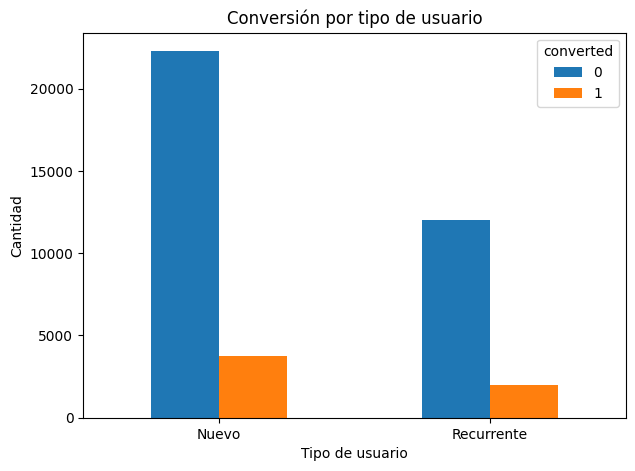

In [37]:
#Tipo de usuario vs conversión
pd.crosstab(df["user_type"], df["converted"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

- El gráfico permite comparar el número de usuarios convertidos y no convertidos según el tipo de usuario. Se observan diferencias entre los segmentos, las cuales pueden explicar la asociación encontrada en la prueba de hipótesis.

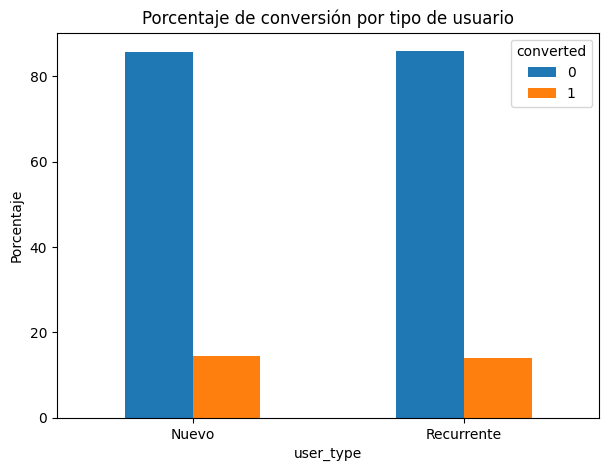

In [38]:
#Porcentajes
(
pd.crosstab(
    df["user_type"],
    df["converted"],
    normalize="index"
)*100).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Porcentaje de conversión por tipo de usuario")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

-El gráfico de proporciones facilita la comparación entre tipos de usuario al eliminar el efecto del tamaño de cada grupo. El segmento con mayor porcentaje de conversión representa una mejor oportunidad para orientar futuras campañas de marketing.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1: Los usuarios que realizaron una conversión presentan un gasto promedio superior al esperado para clientes no convertidos.
- Observacion 2: La página B mantiene un desempeño favorable tanto en conversión como en generación de ingresos.
- **Interpretación:**
  - La página B representa la mejor alternativa para maximizar el retorno del experimento A/B.
<br>

**Tasa de conversión:** 
- Observacion 1: La página B alcanzó una tasa de conversión aproximada del 15.96%, mientras que la página A obtuvo alrededor del 12.57%.
- Observacion 2: La diferencia fue estadísticamente significativa según la prueba Z de dos proporciones.
- **Interpretación:**
  - Se recomienda implementar la página B como versión definitiva del sitio, ya que genera un mayor porcentaje de conversiones.
---

#### 📊 **Segmentación por fuente de tráfico**
- Observacion: Email registró la mayor tasa de conversión (14.99%), seguido por Ads (14.74%). Referral y Organic obtuvieron tasas ligeramente menores.
- **Interpretación:**
  - Conviene priorizar las campañas de Email y Ads, ya que ofrecen un mejor desempeño en términos de conversión.
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion: La prueba Chi-cuadrado mostró que el tipo de usuario está relacionado con la probabilidad de conversión, indicando que algunos segmentos convierten mejor que otros.
- **Interpretación:**
  - Es recomendable personalizar las campañas según el perfil del usuario para mejorar la efectividad de las acciones de marketing.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Implementar la página B como versión principal, ya que obtuvo una tasa de conversión significativamente mayor que la página A.
- Incrementar la inversión en Email y Ads, al ser los canales con mayor efectividad para generar conversiones.
- Desarrollar estrategias segmentadas por tipo de usuario, adaptando mensajes y promociones para cada perfil con el objetivo de aumentar la conversión.
- Realizar pruebas A/B continuas sobre el diseño de la página y las campañas de adquisición para seguir optimizando la experiencia del usuario y maximizar el retorno de la inversión.